In [1]:

import numpy as np

def inverted_normal_curve(x, grid_size, floor=2.0, sigma=None):
    if sigma is None:
        sigma = max(grid_size / 4, 0.5)
    center = grid_size / 2
    peak = max(floor + 0.5, grid_size - 1)
    return floor + (peak - floor) * np.exp(-0.5 * ((x - center) / sigma) ** 2)

def distribute_humans(grid_size, num_humans, floor=2.0):
    # All valid x columns and their max y under the curve
    xs = np.arange(grid_size)
    upper = inverted_normal_curve(xs, grid_size, floor=floor)
    y_min = int(round(floor))
    y_max = np.clip(np.round(upper).astype(int), y_min, grid_size - 1)

    # Count of valid y's per column, then build (y, x) for every point
    counts = np.maximum(y_max - y_min + 1, 0)
    cols = np.repeat(xs, counts)
    # classic "ranges from counts" trick: 0..c0-1, 0..c1-1, ... then shift by y_min
    rows = np.arange(counts.sum()) - np.repeat(np.cumsum(counts) - counts, counts) + y_min
    all_points = np.column_stack([rows, cols])

    # Pick num_humans of them without replacement
    n = min(num_humans, len(all_points))
    idx = np.random.choice(len(all_points), size=n, replace=False)
    return all_points[idx]

In [2]:
import numpy as np

def distribute_humans_2(grid_size, num_humans):
    """Place humans across rows 1..grid_size-1 for graduated detour costs.

    Round-robin: 1 human → row 1; G-1 humans → one per row; 
    2*(G-1) humans → two per row; etc. Columns randomized per row.
    """
    n_rows = grid_size - 1  # exclude agent/goal row 0
    if num_humans > n_rows * grid_size:
        raise ValueError(
            f"num_humans={num_humans} exceeds capacity "
            f"{n_rows * grid_size} for grid_size={grid_size}"
        )

    # Round-robin row assignment: shallow first, then wrap
    # row_assignments = [(i % n_rows) + 1 for i in range(num_humans)]
    # Round-robin row assignment: deep first, then wrap
    row_assignments = [
        (n_rows - (i % n_rows)) if (i // n_rows) % 2 else (i % n_rows + 1)
        for i in range(num_humans)
    ]

    # Random distinct columns within each row
    from collections import Counter
    counts = Counter(row_assignments)
    positions = []
    for row, count in counts.items():
        cols = np.random.choice(grid_size, size=count, replace=False)
        for c in cols:
            positions.append([row, c])

    return np.array(sorted(positions, key=lambda p: (p[0], p[1])))

In [3]:

def visualize_human_distribution(grid_size, num_humans):
    human_positions = distribute_humans_2(grid_size, num_humans=num_humans)
    grid = np.zeros((grid_size, grid_size), dtype=str)
    grid [:] = '.'
    grid[0,0] = 'A'
    grid[0, grid.shape[1] - 1] = 'G'
    grid[human_positions[:, 0], human_positions[:, 1]] = 'X'
    print(grid)

In [10]:
visualize_human_distribution(5, 5)

[['A' '.' '.' '.' 'G']
 ['.' '.' '.' 'X' '.']
 ['.' 'X' '.' '.' '.']
 ['.' 'X' '.' '.' '.']
 ['X' '.' '.' 'X' '.']]


In [4]:
import numpy as np
foo = np.array([
 [-6.25, 4.710999965667725],
 [-6.25, 3.5],
 [-4.650000095367432, 3.115499496459961],
 [-2.0899999141693115, 2.2744998931884766],
 [-0.24500000476837158, 1.1899999380111694],
 [0.3149999976158142, 1.011000156402588],
 [0.7124999761581421, 0.37300005555152893],
 [0.9950000047683716, 0.09499992430210114],
 ])
# normalize per column
foo[:, 0] = (foo[:, 0] - foo[:, 0].min()) / (foo[:, 0].max() - foo[:, 0].min())
foo[:, 1] = (foo[:, 1] - foo[:, 1].min()) / (foo[:, 1].max() - foo[:, 1].min())

weight = np.array([0.5, 0.5])
scalarized_q_values = np.dot(foo, weight)
print(scalarized_q_values)

[0.5        0.36882583 0.43759813 0.52317557 0.53303293 0.55229121
 0.51061646 0.5       ]


In [29]:

visualize_human_distribution(grid_size=5, num_humans=5)

[['A' '.' '.' '.' 'G']
 ['.' 'X' '.' '.' '.']
 ['.' '.' '.' '.' 'X']
 ['.' 'X' '.' '.' '.']
 ['X' '.' '.' '.' 'X']]


(array([ 69.,  63.,  75.,  77.,  67.,  72.,  67.,  65.,  62.,  68.,  71.,
         89.,  77.,  75.,  95.,  91.,  78.,  90., 104.,  90.,  97.,  97.,
        113., 101., 105., 104.,  96.,  81.,  96., 104., 110., 109., 130.,
        102., 121., 109., 125., 122., 144., 127., 137., 107., 129., 148.,
        115., 114., 126., 142., 126., 140., 129., 121., 105., 134., 135.,
        127., 125., 120., 137., 143., 115., 125., 128., 123., 110., 114.,
        121., 112., 123., 136.,  97.,  91., 102.,  89.,  88.,  98.,  85.,
        106., 100.,  92., 100.,  98.,  81.,  79., 103.,  96.,  86.,  80.,
         82.,  77.,  68.,  80.,  60.,  56.,  77.,  54.,  63.,  69.,  76.,
         62.]),
 array([2.76855840e-05, 1.00237262e-02, 2.00197669e-02, 3.00158076e-02,
        4.00118482e-02, 5.00078889e-02, 6.00039295e-02, 6.99999702e-02,
        7.99960108e-02, 8.99920515e-02, 9.99880922e-02, 1.09984133e-01,
        1.19980173e-01, 1.29976214e-01, 1.39972255e-01, 1.49968295e-01,
        1.59964336e-01, 1.6996

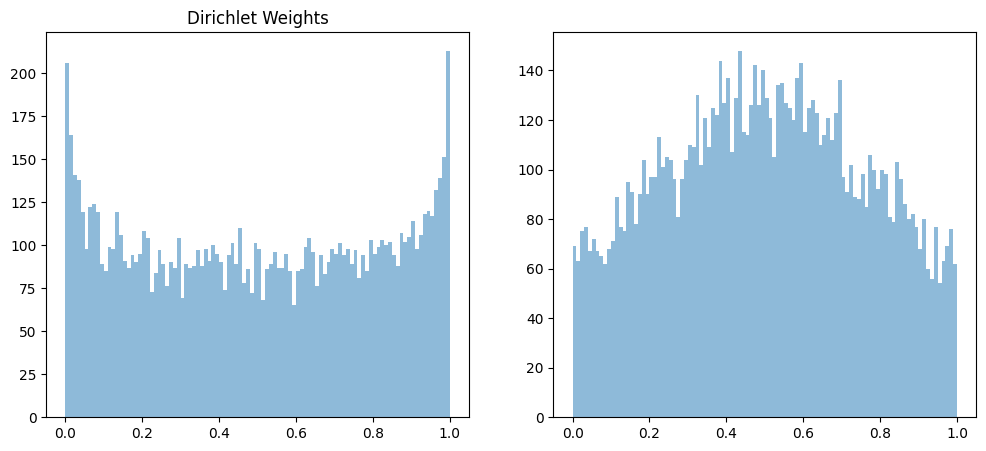

In [52]:
# plot 100 random 2d weights from dirichlet and gaussian distributions to see how they look
from morl_baselines.common.weights import random_weights

rng = np.random.default_rng(42)
dim = 2
dirichlet_weights = rng.dirichlet(np.array([0.8] * 2), 10000)
# dirichlet_weights = random_weights(2, 10000, dist='dirichlet')
gaussian_weights = random_weights(2, 10000, dist='gaussian')


import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(dirichlet_weights[:, 0], bins=100, alpha=0.5)
plt.title('Dirichlet Weights')

plt.subplot(1, 2, 2)
plt.hist(gaussian_weights[:, 0], bins=100, alpha=0.5)

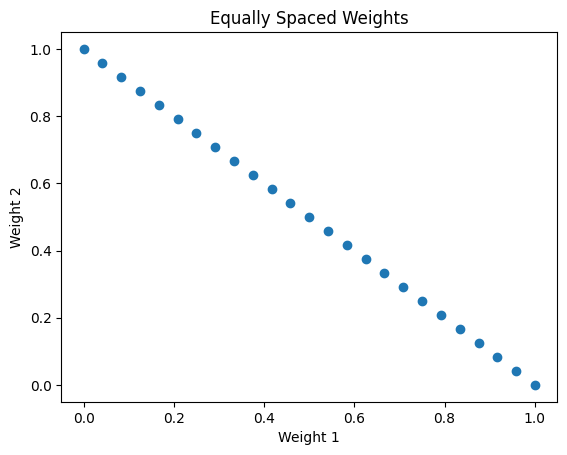

In [55]:
# visualize randomly spaced weights
from morl_baselines.common.weights import equally_spaced_weights

weights = np.array(equally_spaced_weights(2, 25))

plt.scatter(weights[:, 0], weights[:, 1])
plt.xlabel("Weight 1")
plt.ylabel("Weight 2")
plt.title("Equally Spaced Weights")
plt.show()


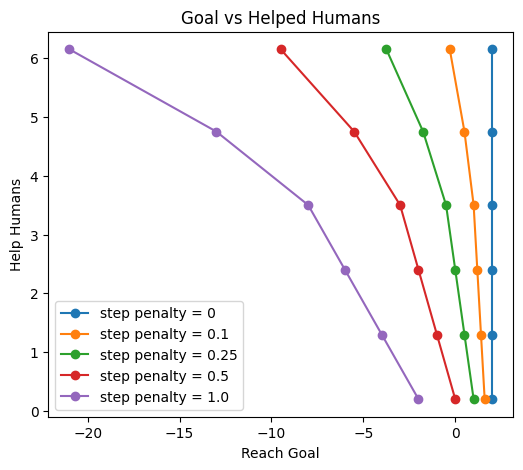

In [44]:
import numpy as np
import matplotlib.pyplot as plt
help_reward= 1
terminal_reward= 2
proximity_reward= 0.05

step_human = np.array([
    np.array([4, 0]),
    np.array([6, 1]),
    np.array([8, 2]),
    np.array([10, 3]),
    np.array([15, 4]),
    np.array([23, 5])
])

# display different step penalties in one plot
plt.figure(figsize=(6, 5))
plt.title('Goal vs Helped Humans')
plt.xlabel('Reach Goal')
plt.ylabel('Help Humans')

for step_penalty in [0, 0.1, 0.25, 0.5, 1.0]:
    x = step_human[:, 0] * -step_penalty + terminal_reward
    y = step_human[:, 1] * help_reward + step_human[:, 0] * proximity_reward
    plt.plot(x, y, marker='o', label=f'step penalty = {step_penalty}')

plt.legend()
plt.show()

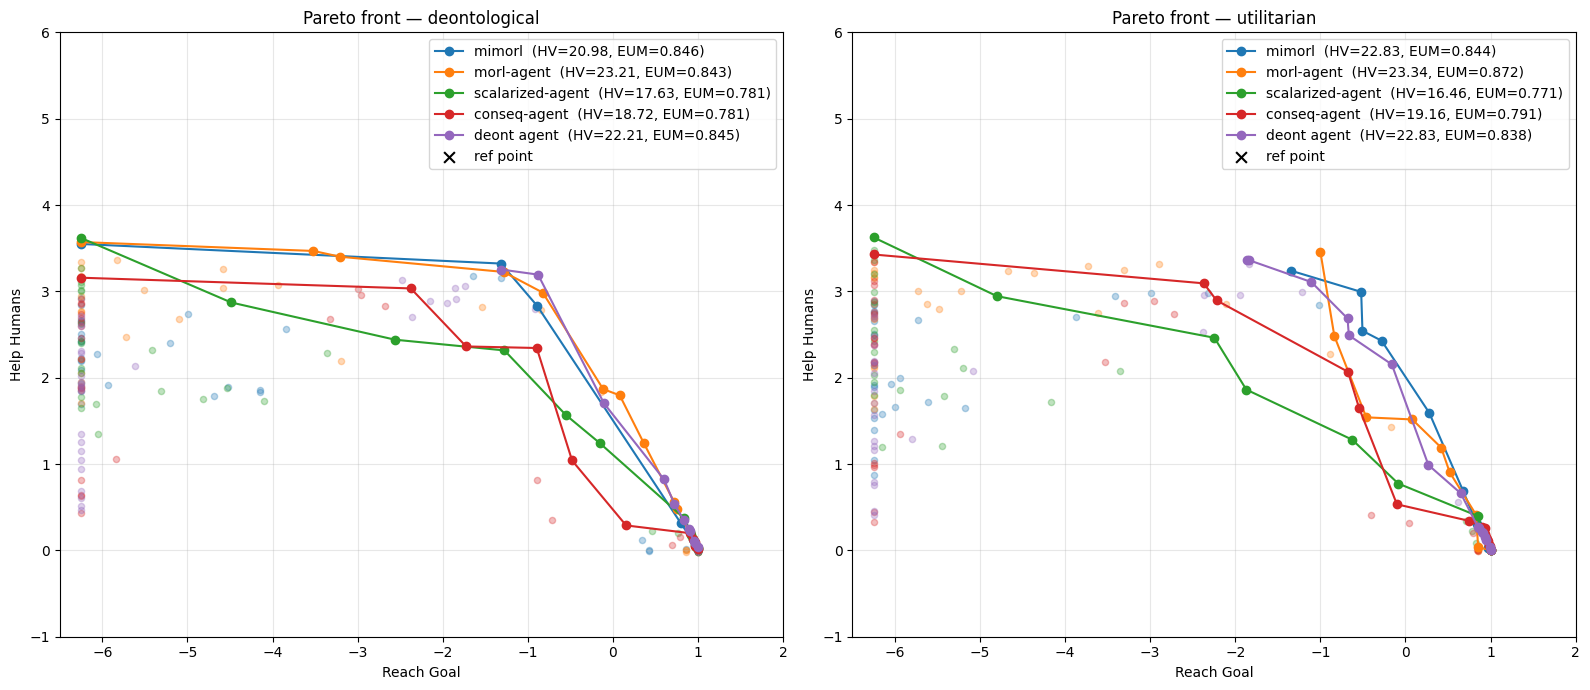

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
from morl_baselines.common.pareto import get_non_dominated
from morl_baselines.common.performance_indicators import hypervolume, expected_utility
from morl_baselines.common.weights import equally_spaced_weights

def pareto_front(points):
    """Return non-dominated points (both objectives maximized), sorted by obj 0."""
    nd = get_non_dominated({tuple(p) for p in np.asarray(points, dtype=float)})
    front = np.array(sorted(nd, key=lambda p: p[0]))
    return front

# (label, dir, {objective: filename}) for each method
methods = [
    ("mimorl",
     r"results\reach_goal\pareto_front\small__400000__6xygky6r",
     {"deontological": "eval_returns_deontological_1.0_0.0.npy",
      "utilitarian":   "eval_returns_utilitarian_0.0_1.0.npy"}),
]
# pareto_front_small runs -> standard eval_returns_<objective>.npy naming
for rid, name in [("382rlbf8", "morl-agent"), ("217jijq9", "scalarized-agent"),
                  ("1nplijz7", "conseq-agent"), ("830lvx42", "deont agent")]:
    methods.append((
        name,
        rf"results\reach_goal\pareto_front_small\small__400000__{rid}",
        {"deontological": "eval_returns_deontological.npy",
         "utilitarian":   "eval_returns_utilitarian.npy"},
    ))

objectives = ["deontological", "utilitarian"]
colors = {label: c for (label, *_), c in
          zip(methods, plt.rcParams["axes.prop_cycle"].by_key()["color"])}

# weights set for the Expected Utility Metric
weights_set = equally_spaced_weights(2, 100)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, objective in zip(axes, objectives):
    loaded = {label: np.load(os.path.join(d, files[objective]))
              for label, d, files in methods}
    # shared min/max per objective across all methods -> fair, comparable metrics
    all_pts = np.vstack(list(loaded.values()))
    lo, hi = all_pts.min(axis=0), all_pts.max(axis=0)
    span = np.where(hi > lo, hi - lo, 1.0)
    ref_point = lo - 0.05 * span  # for HV (raw scale)

    for label, pts in loaded.items():
        ax.scatter(pts[:, 0], pts[:, 1], s=20, alpha=0.3, color=colors[label])
        pf = pareto_front(pts)
        hv = hypervolume(ref_point, pf)
        # EUM on objectives normalized to [0, 1] so each axis contributes comparably
        pf_norm = (pf - lo) / span
        eum = expected_utility(pf_norm, weights_set)
        ax.plot(pf[:, 0], pf[:, 1], marker="o", color=colors[label],
                label=f"{label}  (HV={hv:.2f}, EUM={eum:.3f})")

    ax.scatter(*ref_point, marker="x", color="black", s=60, label="ref point")
    ax.set_title(f"Pareto front — {objective}")
    ax.set_xlabel("Reach Goal")
    ax.set_ylabel("Help Humans")
    ax.set_ylim(-1, 6)
    ax.set_xlim(-6.5, 2)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

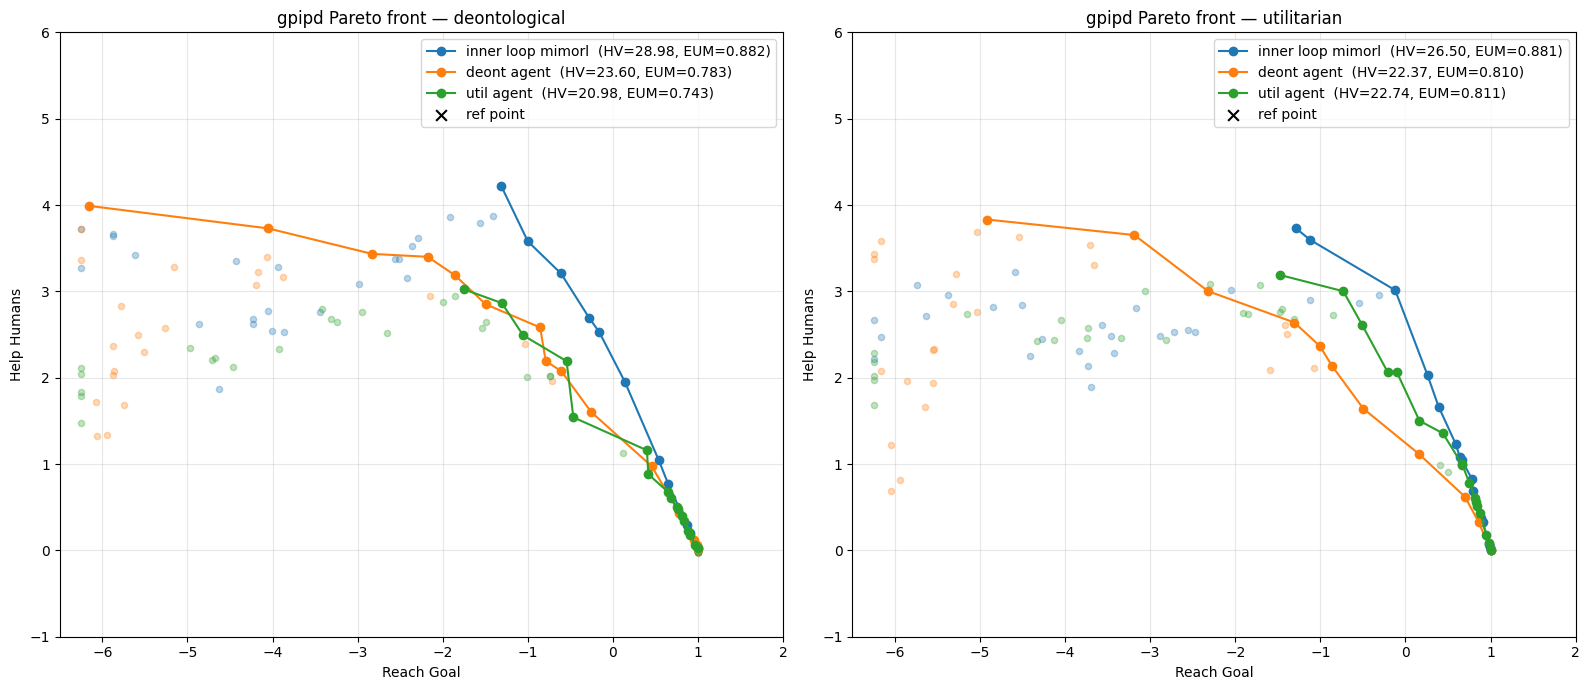

In [22]:
# Same comparison, but for models trained with gpipd
gpipd_methods = [
    ("inner loop mimorl",
     r"results\reach_goal\pareto_front\small__100000__1irjjv6v",
     {"deontological": "eval_returns_deontological_1.0_0.0.npy",
      "utilitarian":   "eval_returns_utilitarian_0.0_1.0.npy"}),
    ("deont agent",
     r"results\reach_goal\pareto_front\small__50000__wdmwio4a",
     {"deontological": "eval_returns_deontological.npy",
      "utilitarian":   "eval_returns_utilitarian.npy"}),
    ("util agent",
     r"results\reach_goal\pareto_front\small__50000__crx4awp6",
     {"deontological": "eval_returns_deontological.npy",
      "utilitarian":   "eval_returns_utilitarian.npy"}),
]

gpipd_colors = {label: c for (label, *_), c in
                zip(gpipd_methods, plt.rcParams["axes.prop_cycle"].by_key()["color"])}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, objective in zip(axes, objectives):
    loaded = {label: np.load(os.path.join(d, files[objective]))
              for label, d, files in gpipd_methods}
    # shared min/max per objective across all methods -> fair, comparable metrics
    all_pts = np.vstack(list(loaded.values()))
    lo, hi = all_pts.min(axis=0), all_pts.max(axis=0)
    span = np.where(hi > lo, hi - lo, 1.0)
    ref_point = lo - 0.05 * span  # for HV (raw scale)

    for label, pts in loaded.items():
        ax.scatter(pts[:, 0], pts[:, 1], s=20, alpha=0.3, color=gpipd_colors[label])
        pf = pareto_front(pts)
        hv = hypervolume(ref_point, pf)
        # EUM on objectives normalized to [0, 1] so each axis contributes comparably
        pf_norm = (pf - lo) / span
        eum = expected_utility(pf_norm, weights_set)
        ax.plot(pf[:, 0], pf[:, 1], marker="o", color=gpipd_colors[label],
                label=f"{label}  (HV={hv:.2f}, EUM={eum:.3f})")

    ax.scatter(*ref_point, marker="x", color="black", s=60, label="ref point")
    ax.set_title(f"gpipd Pareto front — {objective}")
    ax.set_xlabel("Reach Goal")
    ax.set_ylabel("Help Humans")
    ax.set_ylim(-1, 6)
    ax.set_xlim(-6.5, 2)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

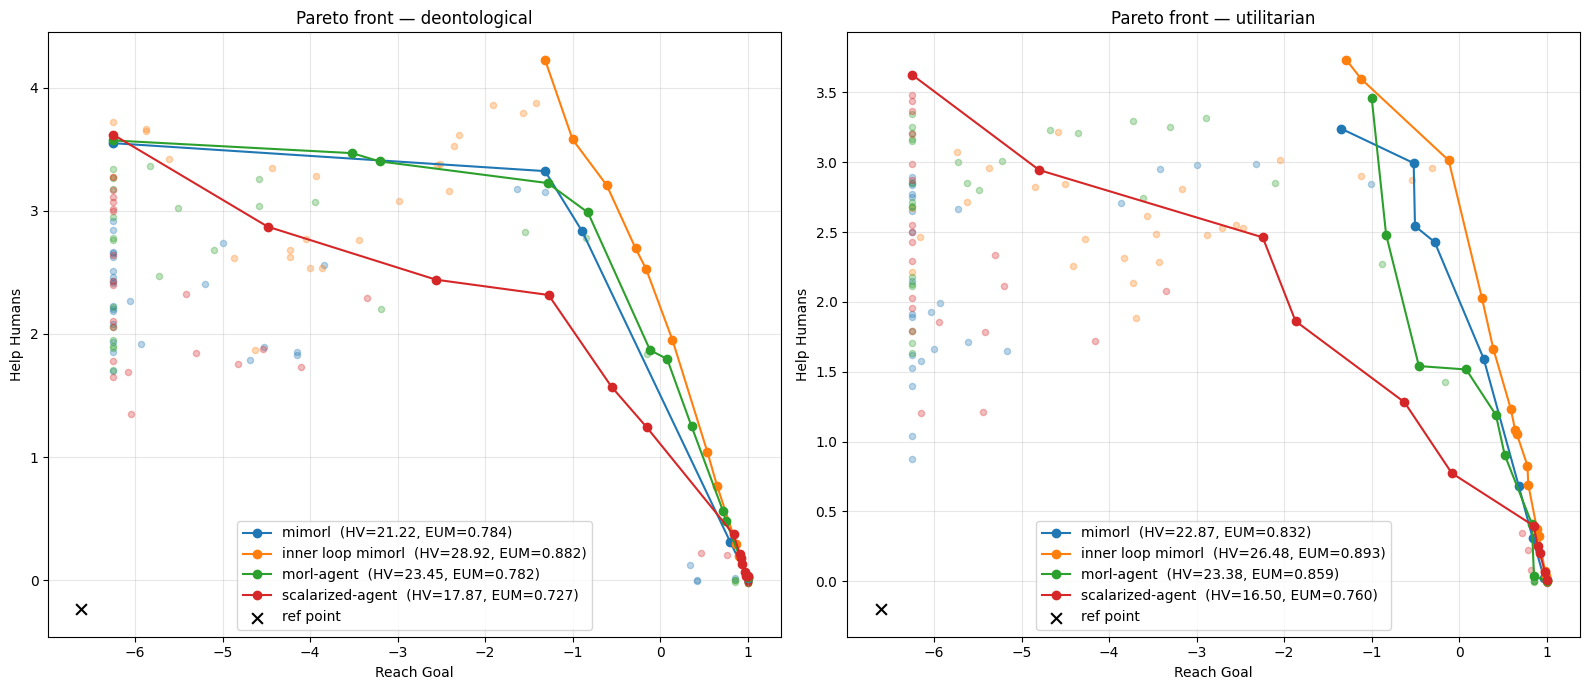

In [23]:
# Compare mimorl vs inner loop mimorl vs morl-agent vs scalarized-agent
cmp_methods = [
    ("mimorl",
     r"results\reach_goal\pareto_front\small__400000__6xygky6r",
     {"deontological": "eval_returns_deontological_1.0_0.0.npy",
      "utilitarian":   "eval_returns_utilitarian_0.0_1.0.npy"}),
    ("inner loop mimorl",
     r"results\reach_goal\pareto_front\small__100000__1irjjv6v",
     {"deontological": "eval_returns_deontological_1.0_0.0.npy",
      "utilitarian":   "eval_returns_utilitarian_0.0_1.0.npy"}),
    ("morl-agent",
     r"results\reach_goal\pareto_front_small\small__400000__382rlbf8",
     {"deontological": "eval_returns_deontological.npy",
      "utilitarian":   "eval_returns_utilitarian.npy"}),
    ("scalarized-agent",
     r"results\reach_goal\pareto_front_small\small__400000__217jijq9",
     {"deontological": "eval_returns_deontological.npy",
      "utilitarian":   "eval_returns_utilitarian.npy"}),
]

cmp_colors = {label: c for (label, *_), c in
              zip(cmp_methods, plt.rcParams["axes.prop_cycle"].by_key()["color"])}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, objective in zip(axes, objectives):
    loaded = {label: np.load(os.path.join(d, files[objective]))
              for label, d, files in cmp_methods}
    # shared min/max per objective across all methods -> fair, comparable metrics
    all_pts = np.vstack(list(loaded.values()))
    lo, hi = all_pts.min(axis=0), all_pts.max(axis=0)
    span = np.where(hi > lo, hi - lo, 1.0)
    ref_point = lo - 0.05 * span  # for HV (raw scale)

    for label, pts in loaded.items():
        ax.scatter(pts[:, 0], pts[:, 1], s=20, alpha=0.3, color=cmp_colors[label])
        pf = pareto_front(pts)
        hv = hypervolume(ref_point, pf)
        # EUM on objectives normalized to [0, 1] so each axis contributes comparably
        pf_norm = (pf - lo) / span
        eum = expected_utility(pf_norm, weights_set)
        ax.plot(pf[:, 0], pf[:, 1], marker="o", color=cmp_colors[label],
                label=f"{label}  (HV={hv:.2f}, EUM={eum:.3f})")

    ax.scatter(*ref_point, marker="x", color="black", s=60, label="ref point")
    ax.set_title(f"Pareto front — {objective}")
    ax.set_xlabel("Reach Goal")
    ax.set_ylabel("Help Humans")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

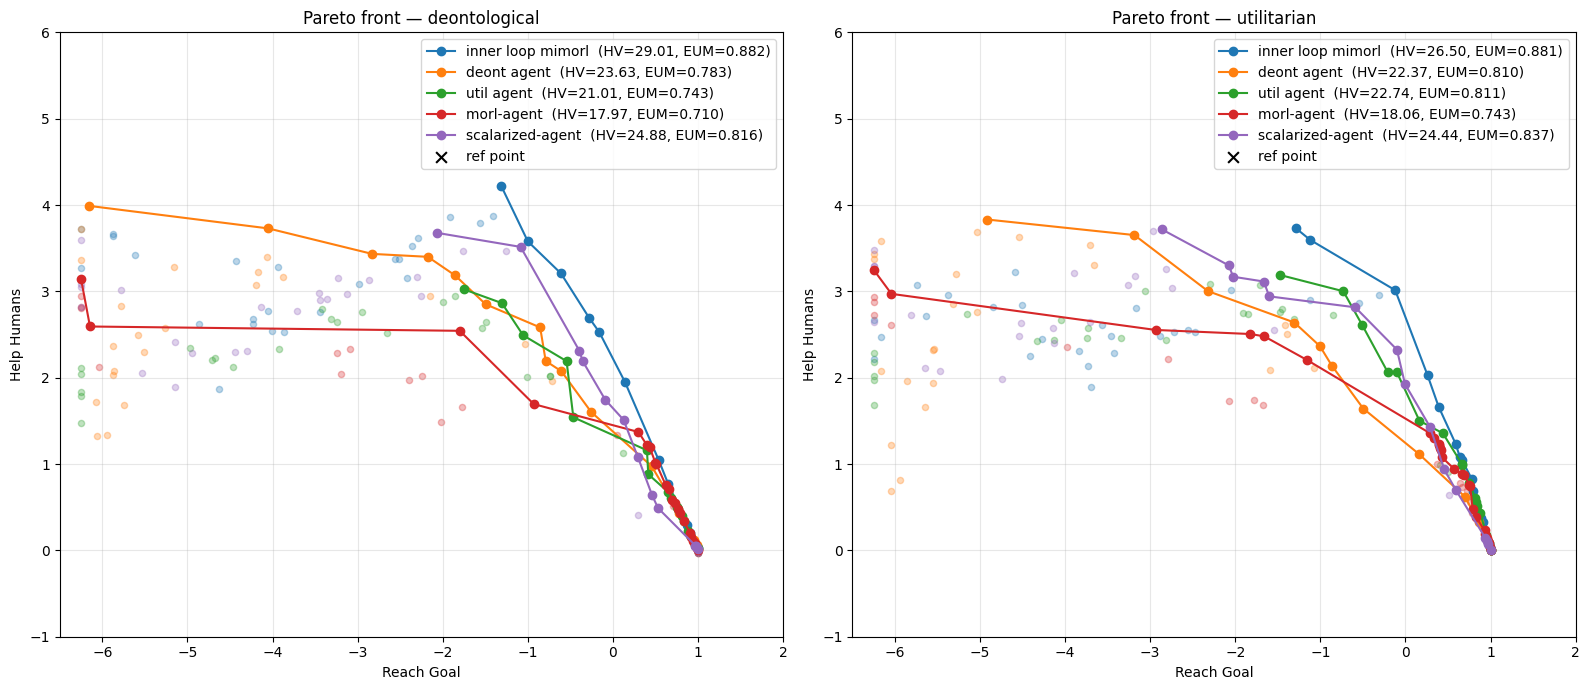

In [25]:
# Compare inner loop mimorl vs deont/util agents vs morl-agent vs scalarized-agent (gpipd)
cmp2_methods = [
    ("inner loop mimorl",
     r"results\reach_goal\pareto_front\small__100000__1irjjv6v",
     {"deontological": "eval_returns_deontological_1.0_0.0.npy",
      "utilitarian":   "eval_returns_utilitarian_0.0_1.0.npy"}),
    ("deont agent",
     r"results\reach_goal\pareto_front\small__50000__wdmwio4a",
     {"deontological": "eval_returns_deontological.npy",
      "utilitarian":   "eval_returns_utilitarian.npy"}),
    ("util agent",
     r"results\reach_goal\pareto_front\small__50000__crx4awp6",
     {"deontological": "eval_returns_deontological.npy",
      "utilitarian":   "eval_returns_utilitarian.npy"}),
    ("morl-agent",
     r"results\reach_goal\pareto_front\small__50000__gihr7l3b",
     {"deontological": "eval_returns_deontological.npy",
      "utilitarian":   "eval_returns_utilitarian.npy"}),
    ("scalarized-agent",
     r"results\reach_goal\pareto_front\small__50000__msuw87fi",
     {"deontological": "eval_returns_deontological.npy",
      "utilitarian":   "eval_returns_utilitarian.npy"}),
]

cmp2_colors = {label: c for (label, *_), c in
               zip(cmp2_methods, plt.rcParams["axes.prop_cycle"].by_key()["color"])}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, objective in zip(axes, objectives):
    loaded = {label: np.load(os.path.join(d, files[objective]))
              for label, d, files in cmp2_methods}
    # shared min/max per objective across all methods -> fair, comparable metrics
    all_pts = np.vstack(list(loaded.values()))
    lo, hi = all_pts.min(axis=0), all_pts.max(axis=0)
    span = np.where(hi > lo, hi - lo, 1.0)
    ref_point = lo - 0.05 * span  # for HV (raw scale)

    for label, pts in loaded.items():
        ax.scatter(pts[:, 0], pts[:, 1], s=20, alpha=0.3, color=cmp2_colors[label])
        pf = pareto_front(pts)
        hv = hypervolume(ref_point, pf)
        # EUM on objectives normalized to [0, 1] so each axis contributes comparably
        pf_norm = (pf - lo) / span
        eum = expected_utility(pf_norm, weights_set)
        ax.plot(pf[:, 0], pf[:, 1], marker="o", color=cmp2_colors[label],
                label=f"{label}  (HV={hv:.2f}, EUM={eum:.3f})")

    ax.scatter(*ref_point, marker="x", color="black", s=60, label="ref point")
    ax.set_title(f"Pareto front — {objective}")
    ax.set_xlabel("Reach Goal")
    ax.set_ylabel("Help Humans")
    ax.set_xlim(-6.5, 2)
    ax.set_ylim(-1, 6)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

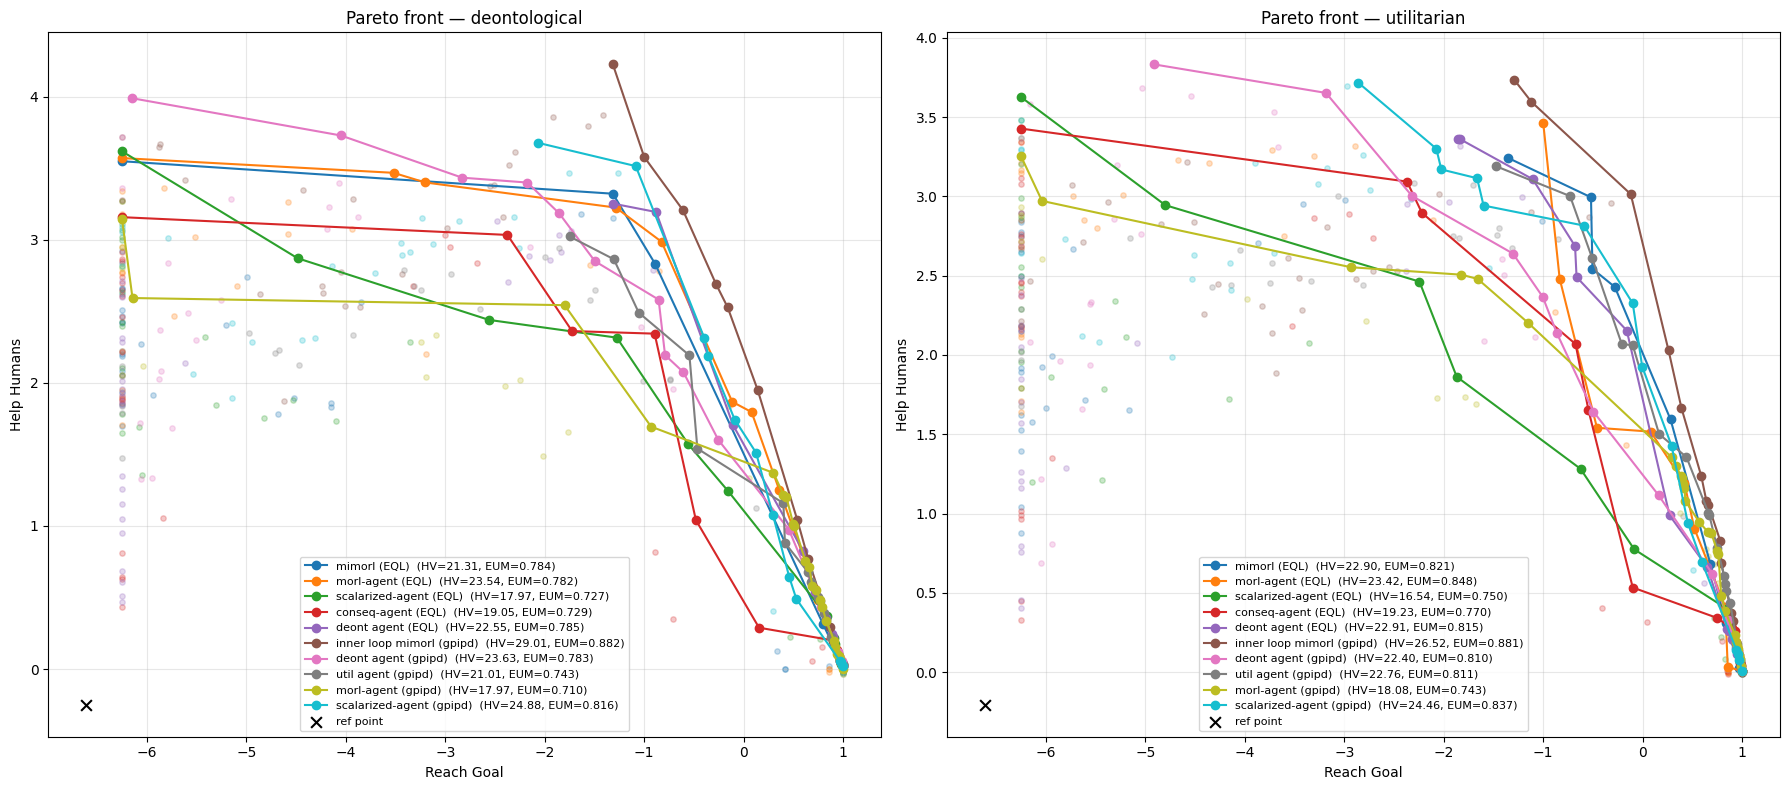

In [26]:
# All methods together: EQL runs + gpipd runs (suffixes keep duplicate names distinct)
all_methods = [
    # ---- EQL runs ----
    ("mimorl (EQL)",
     r"results\reach_goal\pareto_front\small__400000__6xygky6r",
     {"deontological": "eval_returns_deontological_1.0_0.0.npy",
      "utilitarian":   "eval_returns_utilitarian_0.0_1.0.npy"}),
]
for rid, name in [("382rlbf8", "morl-agent"), ("217jijq9", "scalarized-agent"),
                  ("1nplijz7", "conseq-agent"), ("830lvx42", "deont agent")]:
    all_methods.append((
        f"{name} (EQL)",
        rf"results\reach_goal\pareto_front_small\small__400000__{rid}",
        {"deontological": "eval_returns_deontological.npy",
         "utilitarian":   "eval_returns_utilitarian.npy"},
    ))
# ---- gpipd runs ----
all_methods += [
    ("inner loop mimorl (gpipd)",
     r"results\reach_goal\pareto_front\small__100000__1irjjv6v",
     {"deontological": "eval_returns_deontological_1.0_0.0.npy",
      "utilitarian":   "eval_returns_utilitarian_0.0_1.0.npy"}),
]
for rid, name in [("wdmwio4a", "deont agent"), ("crx4awp6", "util agent"),
                  ("gihr7l3b", "morl-agent"), ("msuw87fi", "scalarized-agent")]:
    all_methods.append((
        f"{name} (gpipd)",
        rf"results\reach_goal\pareto_front\small__50000__{rid}",
        {"deontological": "eval_returns_deontological.npy",
         "utilitarian":   "eval_returns_utilitarian.npy"},
    ))

# distinct colors for 10 methods (tab10)
all_colors = {label: c for (label, *_), c in
              zip(all_methods, plt.cm.tab10(np.linspace(0, 1, 10)))}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, objective in zip(axes, objectives):
    loaded = {label: np.load(os.path.join(d, files[objective]))
              for label, d, files in all_methods}
    # shared min/max per objective across all methods -> fair, comparable metrics
    all_pts = np.vstack(list(loaded.values()))
    lo, hi = all_pts.min(axis=0), all_pts.max(axis=0)
    span = np.where(hi > lo, hi - lo, 1.0)
    ref_point = lo - 0.05 * span  # for HV (raw scale)

    for label, pts in loaded.items():
        ax.scatter(pts[:, 0], pts[:, 1], s=15, alpha=0.25, color=all_colors[label])
        pf = pareto_front(pts)
        hv = hypervolume(ref_point, pf)
        # EUM on objectives normalized to [0, 1] so each axis contributes comparably
        pf_norm = (pf - lo) / span
        eum = expected_utility(pf_norm, weights_set)
        ax.plot(pf[:, 0], pf[:, 1], marker="o", color=all_colors[label],
                label=f"{label}  (HV={hv:.2f}, EUM={eum:.3f})")

    ax.scatter(*ref_point, marker="x", color="black", s=60, label="ref point")
    ax.set_title(f"Pareto front — {objective}")
    ax.set_xlabel("Reach Goal")
    ax.set_ylabel("Help Humans")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

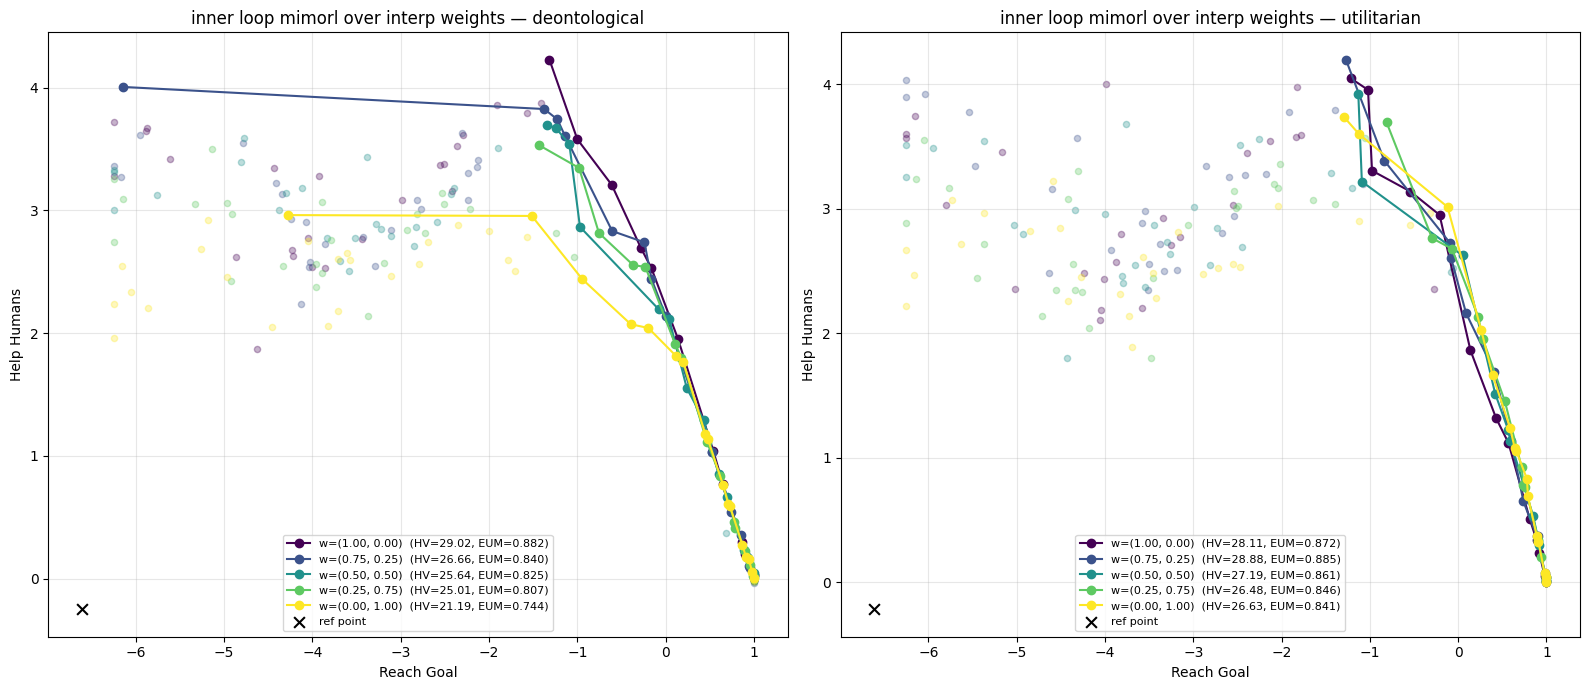

In [27]:
# inner loop mimorl (1irjjv6v) across interpolation weights
interp_dir = r"results\reach_goal\pareto_front\small__100000__1irjjv6v"
# (w0, w1) strings exactly as they appear in the filenames
interp_weights = [
    ("1.0", "0.0"),
    ("0.7506376880696434", "0.24936231193035674"),
    ("0.49938163300153077", "0.5006183669984693"),
    ("0.24878132918207052", "0.7512186708179296"),
    ("0.0", "1.0"),
]

interp_colors = {w: c for w, c in
                 zip(interp_weights, plt.cm.viridis(np.linspace(0, 1, len(interp_weights))))}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, objective in zip(axes, objectives):
    loaded = {w: np.load(os.path.join(
                  interp_dir, f"eval_returns_{objective}_{w[0]}_{w[1]}.npy"))
              for w in interp_weights}
    # shared min/max per objective across all weights -> fair, comparable metrics
    all_pts = np.vstack(list(loaded.values()))
    lo, hi = all_pts.min(axis=0), all_pts.max(axis=0)
    span = np.where(hi > lo, hi - lo, 1.0)
    ref_point = lo - 0.05 * span  # for HV (raw scale)

    for w, pts in loaded.items():
        label = f"w=({float(w[0]):.2f}, {float(w[1]):.2f})"
        ax.scatter(pts[:, 0], pts[:, 1], s=20, alpha=0.3, color=interp_colors[w])
        pf = pareto_front(pts)
        hv = hypervolume(ref_point, pf)
        # EUM on objectives normalized to [0, 1] so each axis contributes comparably
        pf_norm = (pf - lo) / span
        eum = expected_utility(pf_norm, weights_set)
        ax.plot(pf[:, 0], pf[:, 1], marker="o", color=interp_colors[w],
                label=f"{label}  (HV={hv:.2f}, EUM={eum:.3f})")

    ax.scatter(*ref_point, marker="x", color="black", s=60, label="ref point")
    ax.set_title(f"inner loop mimorl over interp weights — {objective}")
    ax.set_xlabel("Reach Goal")
    ax.set_ylabel("Help Humans")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()